# Tugas Akhir Kecerdasan Artifisial — Neural Network

## Prediksi Penyakit Jantung Menggunakan Artificial Neural Network (ANN)

**Dataset:** Heart Disease UCI (Kaggle)
**Fokus Studi:** Klasifikasi Penyakit Jantung
**Model:** Artificial Neural Network (ANN)

### Studi Kasus

Penyakit jantung merupakan salah satu penyebab kematian tertinggi di dunia. Pada penelitian ini digunakan dataset Heart Disease UCI untuk membangun model Artificial Neural Network (ANN) yang mampu memprediksi kemungkinan seseorang menderita penyakit jantung berdasarkan data medis pasien. Model dievaluasi menggunakan Accuracy, Precision, Recall, F1-Score, Confusion Matrix, dan ROC-AUC untuk mengukur performa klasifikasi.


In [6]:
# ==========================================
# 1. IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# ==========================================
# 3. LOAD DATASET
# ==========================================

file_id = "1PVbj-pbytZIr4pWGqiHAS0mkVHGwAD1a"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

print("Shape Dataset :", df.shape)

display(df.head())

Shape Dataset : (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
# ==========================================
# 4. DATA UNDERSTANDING
# ==========================================

print("\nInfo Dataset")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistik Deskriptif")
display(df.describe())


Info Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     5

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
# ==========================================
# 5. DATA PREPROCESSING
# ==========================================

df = df.dropna()

# Hapus kolom yang tidak diperlukan
for col in ['id', 'dataset']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [10]:
# ==========================================
# 6. ENCODING DATA KATEGORIK
# ==========================================

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [11]:
# ==========================================
# 7. MEMBUAT TARGET BINER
# ==========================================

if 'num' in df.columns:
    df['target'] = np.where(df['num'] > 0, 1, 0)
    df.drop('num', axis=1, inplace=True)

In [12]:
# ==========================================
# 8. FEATURE DAN TARGET
# ==========================================

X = df.drop('target', axis=1)
y = df['target']

print("\nJumlah Fitur :", X.shape[1])


Jumlah Fitur : 13


In [13]:
# ==========================================
# 9. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# ==========================================
# 10. NORMALISASI DATA
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# ==========================================
# 11. CLASS WEIGHT
# ==========================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {
    0: weights[0],
    1: weights[1]
}

print("\nClass Weight")
print(class_weight_dict)


Class Weight
{0: np.float64(0.93359375), 1: np.float64(1.0765765765765767)}


In [16]:
# ==========================================
# 12. MEMBANGUN NEURAL NETWORK
# ==========================================

model = Sequential()

model.add(
    Dense(
        32,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)

model.add(Dropout(0.3))

model.add(
    Dense(
        16,
        activation='relu'
    )
)

model.add(Dropout(0.2))

model.add(
    Dense(
        8,
        activation='relu'
    )
)

model.add(Dropout(0.1))

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

c:\laragon\bin\python\python-3.10\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# ==========================================
# 13. COMPILE MODEL
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary")
model.summary()


Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ==========================================
# 14. EARLY STOPPING
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [19]:
# ==========================================
# 15. TRAINING MODEL
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4188 - loss: 0.7206 - val_accuracy: 0.5833 - val_loss: 0.6840
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5236 - loss: 0.6825 - val_accuracy: 0.5625 - val_loss: 0.6675
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5602 - loss: 0.6470 - val_accuracy: 0.6042 - val_loss: 0.6513
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5812 - loss: 0.6333 - val_accuracy: 0.6667 - val_loss: 0.6327
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6702 - loss: 0.6116 - val_accuracy: 0.6458 - val_loss: 0.6164
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6911 - loss: 0.5999 - val_accuracy: 0.7083 - val_loss: 0.6013
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7644 - loss: 0.5468 - val_accuracy: 0.6875 - val_loss: 0.5839
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7435 - loss: 0.5379 - val_accuracy: 0.6667 - 

In [20]:
# ==========================================
# 16. EVALUASI MODEL
# ==========================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n========================")
print("HASIL EVALUASI MODEL")
print("========================")
print("Loss     :", round(loss, 4))
print("Accuracy :", round(accuracy, 4))


HASIL EVALUASI MODEL
Loss     : 0.3765
Accuracy : 0.8667


In [21]:
# ==========================================
# 17. PREDIKSI
# ==========================================

y_pred_prob = model.predict(X_test)

# Threshold lebih sensitif
y_pred = (y_pred_prob > 0.4).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [22]:
# ==========================================
# 18. METRIK EVALUASI
# ==========================================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n========================")
print("METRIK EVALUASI")
print("========================")
print("Accuracy  :", round(acc, 4))
print("Precision :", round(prec, 4))
print("Recall    :", round(rec, 4))
print("F1 Score  :", round(f1, 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


METRIK EVALUASI
Accuracy  : 0.8667
Precision : 0.8571
Recall    : 0.8571
F1 Score  : 0.8571

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        32
           1       0.86      0.86      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



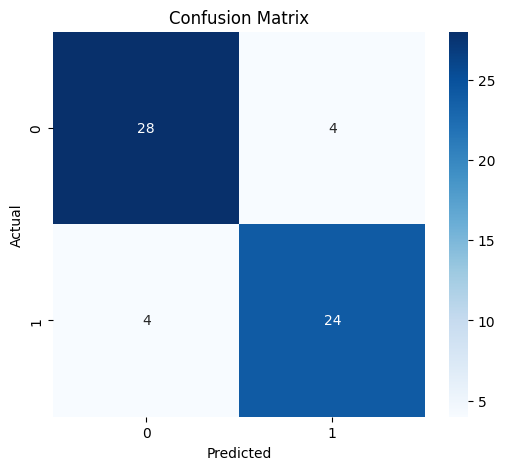

In [23]:
# ==========================================
# 19. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

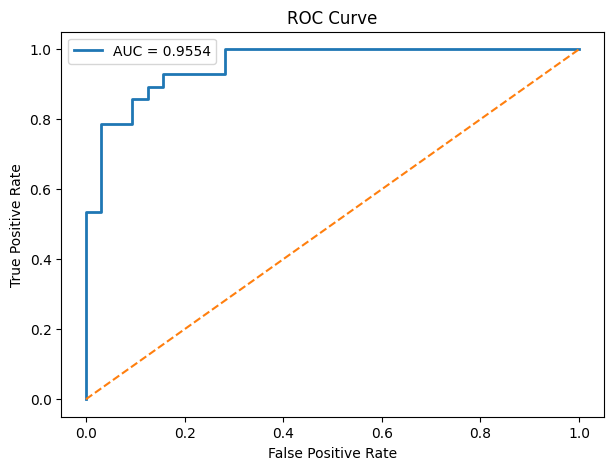

AUC Score : 0.9554


In [24]:
# ==========================================
# 20. ROC CURVE DAN AUC
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score :", round(roc_auc, 4))

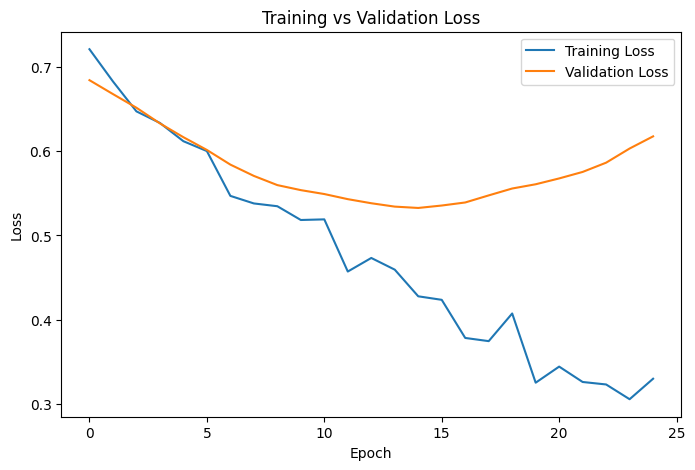

In [25]:
# ==========================================
# 21. GRAFIK LOSS
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

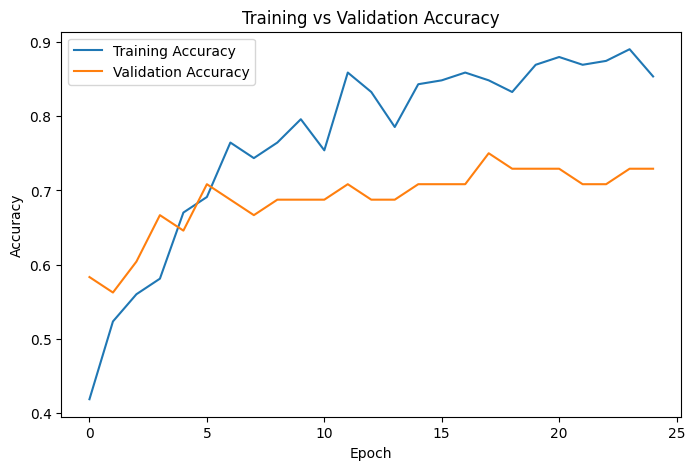

In [26]:
# ==========================================
# 22. GRAFIK ACCURACY
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()